In [1]:
from ppg_basis import ppgGenerator
from ppg_basis import ppgExtractor
import matplotlib.pyplot as plt

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),Intel(R) Iris(R) Xe Graphics (RPL-U),IntegratedGPU,Vulkan,Mesa 25.2.1-arch1.4
❌,Mesa Intel(R) Iris(R) Xe Graphics (RPL-U),IntegratedGPU,OpenGL,4.6 (Core Profile) Mesa 25.2.1-arch1.4


/home/bai/Desktop/ppg-basis/ppg_basis/utils/ppg_utils.py:10: UserWarning: sigma parameter is invalid (0), defaulting to 0
  warnings.warn(f'{name} parameter is invalid ({value}), defaulting to {default_params[name]}', UserWarning)


Text(0.5, 1.0, 'Original PPG')

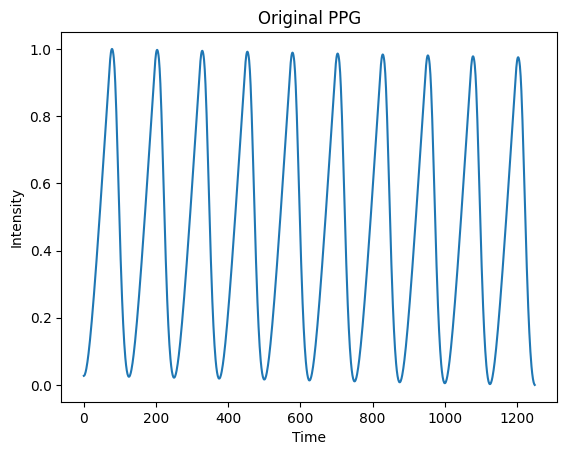

In [2]:
# Generate signal
ppgGen = ppgGenerator(fs=125,
                      hr=60,
                      mu=1,
                      sigma=0,
                      duration=10,
                      L=3,
                      basis_type="gamma",
                      solver="fft")

sig = ppgGen.generate_signal()
plt.plot(sig)
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.title("Original PPG")

In [3]:
# Extract signal parameters
ppgExt = ppgExtractor(signal=sig,
                      fs=125,
                      hr=60,
                      sigma=0,
                      L=3,
                      basis_type='gamma',
                      solver="fft",
                     cost_metrics=["mse", "corr", "kendall"])

/home/bai/Desktop/ppg-basis/ppg_basis/utils/ppg_utils.py:10: UserWarning: cost_func parameter is invalid (None), defaulting to None
  warnings.warn(f'{name} parameter is invalid ({value}), defaulting to {default_params[name]}', UserWarning)


In [4]:
display = False
if display:
    views = ppgExt.plot_cost_landscape()
    for v in views:
        display(v)

In [5]:
ppgExt.cost_metrics = ["mse", "corr", "kendall"]
theta_pred, params_pred = ppgExt.extract_ppg(block_update=True, 
                                             coord_cycles=4)

/home/bai/Desktop/ppg-basis/ppg_basis/utils/ppg_utils.py:10: UserWarning: sigma parameter is invalid (0), defaulting to 0
  warnings.warn(f'{name} parameter is invalid ({value}), defaulting to {default_params[name]}', UserWarning)


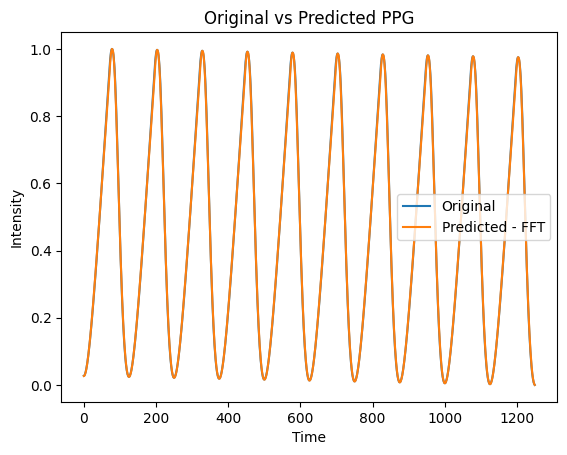

In [6]:
# Generate PPG using extracted parameters
ppgPrd = ppgGenerator(fs=125,
                      hr=60,
                      mu=1,
                      sigma=0,
                      duration=10,
                      L=3,
                      basis_type="gamma",
                      thetas=theta_pred,
                      params=params_pred,
                      solver="fft")
pred = ppgPrd.generate_signal()

plt.plot(sig)
plt.plot(pred)
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.title("Original vs Predicted PPG")
plt.legend(["Original", "Predicted - FFT"])